# Solución ejercicios

En este notebook se resolvieron los ejercicios de regresión lineal y regularización usando el dataset `notebooks/data.csv`.
Se aplico una transformación logarítmica al target `MSRP` y se guardaron los resultados en la carpeta `ENTREGA`.

In [ ]:
#Se importan las librerías necesarias para el análisis de datos, la preparación de los datos, la construcción del modelo y la evaluación del modelo. También se busca el archivo 'data.csv' en varias rutas posibles y se carga en un DataFrame de pandas.
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
import os
# Se busca el archivo 'data.csv' en varias rutas posibles y se carga en un DataFrame de pandas
for _candidate in ['data.csv', 'notebooks/data.csv', 'ENTREGA/data.csv']:
    if os.path.exists(_candidate):
        path = _candidate
        break
else:
    raise FileNotFoundError("No se encontró data.csv en ninguna ruta esperada")
# Se carga el archivo CSV en un DataFrame de pandas y se muestra las primeras filas del DataFrame para verificar que se ha cargado correctamente.
df = pd.read_csv(path)
df.head()

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [ ]:
# Se muestra la forma del DataFrame, las columnas disponibles y la cantidad de valores nulos por columna para entender mejor la estructura de los datos y detectar posibles problemas de calidad de los datos.
print('Shape:', df.shape)
print('Columnas:')
print(df.columns.tolist())
print('Valores nulos por columna:')
print(df.isna().sum())

Shape: (11914, 15)
Columnas:
['Year', 'Engine HP', 'Engine Cylinders', 'Transmission Type', 'Driven_Wheels', 'Number of Doors', 'Market Category', 'Vehicle Size', 'Vehicle Style', 'highway MPG', 'city mpg', 'Popularity', 'Make', 'MSRP', 'log_MSRP']
Valores nulos por columna:
Year                    0
Engine HP              69
Engine Cylinders       30
Transmission Type       0
Driven_Wheels           0
Number of Doors         6
Market Category      3742
Vehicle Size            0
Vehicle Style           0
highway MPG             0
city mpg                0
Popularity              0
Make                    0
MSRP                    0
log_MSRP                0
dtype: int64


## Ejercicio 1: Preparación de datos
1. Carga el dataset y muestra las primeras 5 filas.
2. Identifica columnas nulas.
3. Transforma el target con logaritmo natural.
4. Divide en `train` 60%, `val` 20% y `test` 20%.

In [ ]:
# Se crea una nueva columna 'log_MSRP' que contiene el logaritmo natural del precio de venta al público (MSRP) para estabilizar la varianza y mejorar la distribución de los datos. Luego se seleccionan las columnas relevantes para el análisis y se dividen los datos en conjuntos de entrenamiento, validación y prueba.
df = df.copy()
df['log_MSRP'] = np.log1p(df['MSRP'])
cols = ['Year', 'Engine HP', 'Engine Cylinders', 'Transmission Type', 'Driven_Wheels', 'Number of Doors',
        'Market Category', 'Vehicle Size', 'Vehicle Style', 'highway MPG', 'city mpg', 'Popularity', 'Make']
df = df[cols + ['MSRP', 'log_MSRP']]
# Se dividen los datos en conjuntos de entrenamiento, validación y prueba utilizando la función train_test_split de scikit-learn. El conjunto de prueba se reserva para la evaluación final del modelo, mientras que el conjunto de validación se utiliza para ajustar los hiperparámetros del modelo y prevenir el sobreajuste.
train_val, test = train_test_split(df, test_size=0.20, random_state=42)
train, val = train_test_split(train_val, test_size=0.25, random_state=42)
train.shape, val.shape, test.shape

((7148, 15), (2383, 15), (2383, 15))

## Ejercicio 2: Regresión lineal
1. Entrena un modelo con solo `year` y `engine_hp`.
2. Calcula el RMSE en validación.
3. Agrega 3 features más y compara el RMSE.
4. Interpreta los pesos más grandes.

In [ ]:
# Se define una función rmse que calcula la raíz del error cuadrático medio entre los valores reales y las predicciones del modelo. Esta función se utilizará para evaluar el rendimiento del modelo en el conjunto de validación.
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))
# Se seleccionan las columnas 'Year' y 'Engine HP' para construir un modelo de regresión lineal simple. Se eliminan las filas con valores nulos en estas columnas y en la columna 'log_MSRP' del conjunto de entrenamiento y validación. Luego se entrena el modelo con el conjunto de entrenamiento, se hacen predicciones en el conjunto de validación y se calcula el RMSE para evaluar el rendimiento del modelo. Finalmente, se imprimen los coeficientes del modelo para interpretar la relación entre las características y el precio.
cols2 = ['Year', 'Engine HP']
train2 = train.dropna(subset=cols2 + ['log_MSRP'])
val2 = val.dropna(subset=cols2 + ['log_MSRP'])
model2 = LinearRegression()
model2.fit(train2[cols2], train2['log_MSRP'])
pred_val2 = model2.predict(val2[cols2])
rmse_val2 = rmse(val2['log_MSRP'], pred_val2)
print('RMSE validación (2 features):', rmse_val2)
print('Coeficientes:')
for f, c in zip(cols2, model2.coef_):
    print(f' - {f}: {c}')

RMSE validación (2 features): 0.5260586642406384
Coeficientes:
 - Year: 0.08731065399968271
 - Engine HP: 0.004712666028351737


In [ ]:
# Se seleccionan las columnas 'Year', 'Engine HP', 'Engine Cylinders', 'highway MPG' y 'city mpg' para construir un modelo de regresión lineal múltiple. Se eliminan las filas con valores nulos en estas columnas y en la columna 'log_MSRP' del conjunto de entrenamiento y validación. Luego se entrena el modelo con el conjunto de entrenamiento, se hacen predicciones en el conjunto de validación y se calcula el RMSE para evaluar el rendimiento del modelo. Finalmente, se imprimen los coeficientes del modelo para interpretar la relación entre las características y el precio.
cols5 = cols2 + ['Engine Cylinders', 'highway MPG', 'city mpg']
train5 = train.dropna(subset=cols5 + ['log_MSRP'])
val5 = val.dropna(subset=cols5 + ['log_MSRP'])
model5 = LinearRegression()
model5.fit(train5[cols5], train5['log_MSRP'])
pred_val5 = model5.predict(val5[cols5])
rmse_val5 = rmse(val5['log_MSRP'], pred_val5)
print('RMSE validación (5 features):', rmse_val5)
print('Coeficientes:')
for f, c in zip(cols5, model5.coef_):
    print(f' - {f}: {c}')

RMSE validación (5 features): 0.5219945765373919
Coeficientes:
 - Year: 0.09194907159829663
 - Engine HP: 0.003886039594211918
 - Engine Cylinders: 0.058816810624982126
 - highway MPG: -0.0021008705315588546
 - city mpg: 0.0028807430841820227


## Ejercicio 3: Feature engineering
1. Crea `antiguedad = 2024 - Year`.
2. Aplica One-Hot Encoding a `Make`.
3. Entrena un modelo con todas las features numéricas + `Make` encoded.
4. Compara el RMSE con el modelo del ejercicio 2.

In [15]:
# Se crea una nueva característica 'antiguedad' que representa la antigüedad del vehículo en años, calculada como la diferencia entre el año actual (2024) y el año de fabricación del vehículo. Luego se seleccionan un conjunto de características numéricas y categóricas para construir un modelo de regresión lineal múltiple. Se utilizan técnicas de imputación para manejar los valores nulos en las características numéricas y codificación one-hot para las características categóricas. Finalmente, se entrena el modelo con el conjunto de entrenamiento, se hacen predicciones en el conjunto de validación, se calcula el RMSE para evaluar el rendimiento del modelo y se imprimen los coeficientes ordenados por magnitud para interpretar la importancia de cada característica.
for split in [train, val, test]:
    split['antiguedad'] = 2024 - split['Year']
# Se definen las características numéricas y categóricas, se crean los objetos de codificación e imputación, se transforman los conjuntos de entrenamiento, validación y prueba, se concatenan las características numéricas y categóricas para formar los conjuntos completos, se entrena el modelo de regresión lineal, se hacen predicciones en el conjunto de validación, se calcula el RMSE y se imprimen los coeficientes ordenados por magnitud.
numeric_features = ['antiguedad', 'Engine HP', 'Engine Cylinders', 'Number of Doors', 'highway MPG', 'city mpg', 'Popularity']
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
imputer = SimpleImputer(strategy='median')
# Se transforman las características numéricas utilizando la imputación para manejar los valores nulos y las características categóricas utilizando la codificación one-hot. Luego se concatenan las características numéricas y categóricas para formar los conjuntos completos de entrenamiento, validación y prueba.
X_train_num = pd.DataFrame(imputer.fit_transform(train[numeric_features]), columns=numeric_features, index=train.index)
X_val_num = pd.DataFrame(imputer.transform(val[numeric_features]), columns=numeric_features, index=val.index)
X_test_num = pd.DataFrame(imputer.transform(test[numeric_features]), columns=numeric_features, index=test.index)
# Se transforman las características categóricas utilizando la codificación one-hot. El encoder se ajusta con el conjunto de entrenamiento y luego se transforma el conjunto de validación y prueba utilizando el mismo encoder para asegurar que las mismas categorías se codifiquen de la misma manera en todos los conjuntos.
X_train_cat = pd.DataFrame(encoder.fit_transform(train[['Make']]), columns=encoder.get_feature_names_out(['Make']), index=train.index)
X_val_cat = pd.DataFrame(encoder.transform(val[['Make']]), columns=encoder.get_feature_names_out(['Make']), index=val.index)
X_test_cat = pd.DataFrame(encoder.transform(test[['Make']]), columns=encoder.get_feature_names_out(['Make']), index=test.index)
# Se concatenan las características numéricas y categóricas para formar los conjuntos completos de entrenamiento, validación y prueba. Luego se entrena un modelo de regresión lineal con el conjunto de entrenamiento completo, se hacen predicciones en el conjunto de validación, se calcula el RMSE para evaluar el rendimiento del modelo y se imprimen los coeficientes ordenados por magnitud para interpretar la importancia de cada característica.
X_train_full = pd.concat([X_train_num, X_train_cat], axis=1)
X_val_full = pd.concat([X_val_num, X_val_cat], axis=1)
X_test_full = pd.concat([X_test_num, X_test_cat], axis=1)
# Se entrena un modelo de regresión lineal con el conjunto de entrenamiento completo, se hacen predicciones en el conjunto de validación, se calcula el RMSE para evaluar el rendimiento del modelo y se imprimen los coeficientes ordenados por magnitud para interpretar la importancia de cada característica.
model_full = LinearRegression()
model_full.fit(X_train_full, train['log_MSRP'])
pred_val_full = model_full.predict(X_val_full)
rmse_val_full = rmse(val['log_MSRP'], pred_val_full)
print('RMSE validación (full model):', rmse_val_full)
#
coef_series = pd.Series(model_full.coef_, index=X_train_full.columns).sort_values(key=abs, ascending=False)
print('Top 10 coeficientes por magnitud:')
print(coef_series.head(10).to_string())

RMSE validación (full model): 0.44575169092579786
Top 10 coeficientes por magnitud:
Make_Bugatti        1.700630
Make_Ferrari        1.436340
Make_Spyker         1.346737
Make_Maybach        1.214218
Make_Rolls-Royce    1.042777
Make_Tesla          1.042678
Make_Bentley        0.886935
Make_Plymouth      -0.806605
Make_Lamborghini    0.765074
Make_Genesis       -0.740814


## Ejercicio 4: Regularización
1. Entrena Ridge con valores de alpha = [0.001, 0.01, 0.1, 1, 10, 100].
2. Grafica alpha vs RMSE.
3. Encuentra el mejor alpha.
4. Entrena el modelo final con train+val y reporta RMSE en test.

alpha=0.001 -> RMSE val=0.4457519475058858
alpha=0.01 -> RMSE val=0.4457543059097692
alpha=0.1 -> RMSE val=0.4457823948517679
alpha=1 -> RMSE val=0.4463053478449649
alpha=10 -> RMSE val=0.4531936529274579
alpha=100 -> RMSE val=0.4803526134713386
Mejor alpha: 0.001 RMSE val: 0.4457519475058858


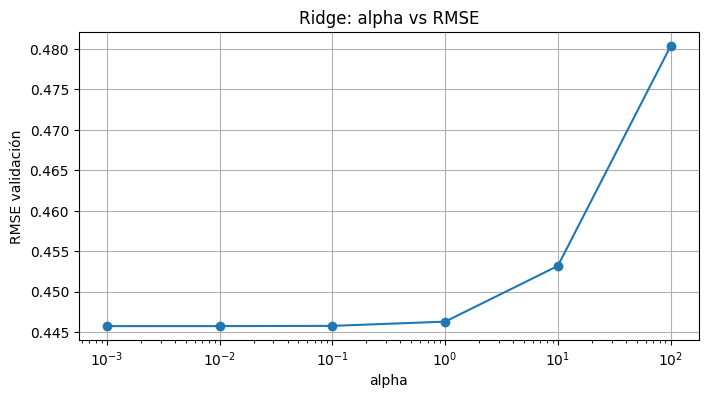

In [16]:
# Se entrena un modelo de regresión Ridge con diferentes valores de alpha para regularizar el modelo y prevenir el sobreajuste. Se evalúa el rendimiento del modelo en el conjunto de validación utilizando el RMSE y se selecciona el mejor valor de alpha basado en el RMSE más bajo. Finalmente, se visualiza la relación entre alpha y RMSE en una gráfica.
alphas = [0.001, 0.01, 0.1, 1, 10, 100]
ridge_scores = []
for alpha in alphas:
    ridge = Ridge(alpha=alpha, random_state=42)
    ridge.fit(X_train_full, train['log_MSRP'])
    pred = ridge.predict(X_val_full)
    score = rmse(val['log_MSRP'], pred)
    ridge_scores.append(score)
    print(f'alpha={alpha} -> RMSE val={score}')
# Se encuentra el mejor valor de alpha que minimiza el RMSE en el conjunto de validación y se imprime el mejor alpha junto con su RMSE. Luego se visualiza la relación entre alpha y RMSE en una gráfica utilizando una escala logarítmica para el eje x.
best_alpha = alphas[np.argmin(ridge_scores)]
best_score = min(ridge_scores)
print('Mejor alpha:', best_alpha, 'RMSE val:', best_score)
# Se visualiza la relación entre alpha y RMSE en una gráfica utilizando una escala logarítmica para el eje x. Esto permite observar cómo varía el rendimiento del modelo con diferentes niveles de regularización y facilita la identificación del mejor valor de alpha.
plt.figure(figsize=(8, 4))
plt.plot(alphas, ridge_scores, marker='o')
plt.xscale('log')
plt.xlabel('alpha')
plt.ylabel('RMSE validación')
plt.title('Ridge: alpha vs RMSE')
plt.grid(True)
plt.show()

In [12]:
train_val_combined = pd.concat([train, val])
imputer_final = SimpleImputer(strategy='median')
X_tv_num = pd.DataFrame(imputer_final.fit_transform(train_val_combined[numeric_features]), columns=numeric_features, index=train_val_combined.index)
X_test_num_final = pd.DataFrame(imputer_final.transform(test[numeric_features]), columns=numeric_features, index=test.index)
encoder_final = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_tv_cat = pd.DataFrame(encoder_final.fit_transform(train_val_combined[['Make']]), columns=encoder_final.get_feature_names_out(['Make']), index=train_val_combined.index)
X_test_cat_final = pd.DataFrame(encoder_final.transform(test[['Make']]), columns=encoder_final.get_feature_names_out(['Make']), index=test.index)

X_tv = pd.concat([X_tv_num, X_tv_cat], axis=1)
X_test_final = pd.concat([X_test_num_final, X_test_cat_final], axis=1)

final_ridge = Ridge(alpha=best_alpha, random_state=42)
final_ridge.fit(X_tv, train_val_combined['log_MSRP'])
pred_test_final = final_ridge.predict(X_test_final)
rmse_test_final = rmse(test['log_MSRP'], pred_test_final)
print('RMSE test final Ridge:', rmse_test_final)

RMSE test final Ridge: 0.4421668356679318


### Gráficas adicionales — Ejercicio 4

| Gráfica | Qué muestra |
|---|---|
| G1 — Predicho vs Real | Qué tan cerca están las predicciones del valor real |
| G2 — Residuos | Si el error está centrado en 0 (modelo sin sesgo) |
| G3 — Coeficientes vs alpha | Cómo la regularización encoge los pesos |
| G4 — Top 15 features | Qué variables más influyen en el precio |
| G5 — Train vs Val RMSE | Punto donde empieza el underfitting |

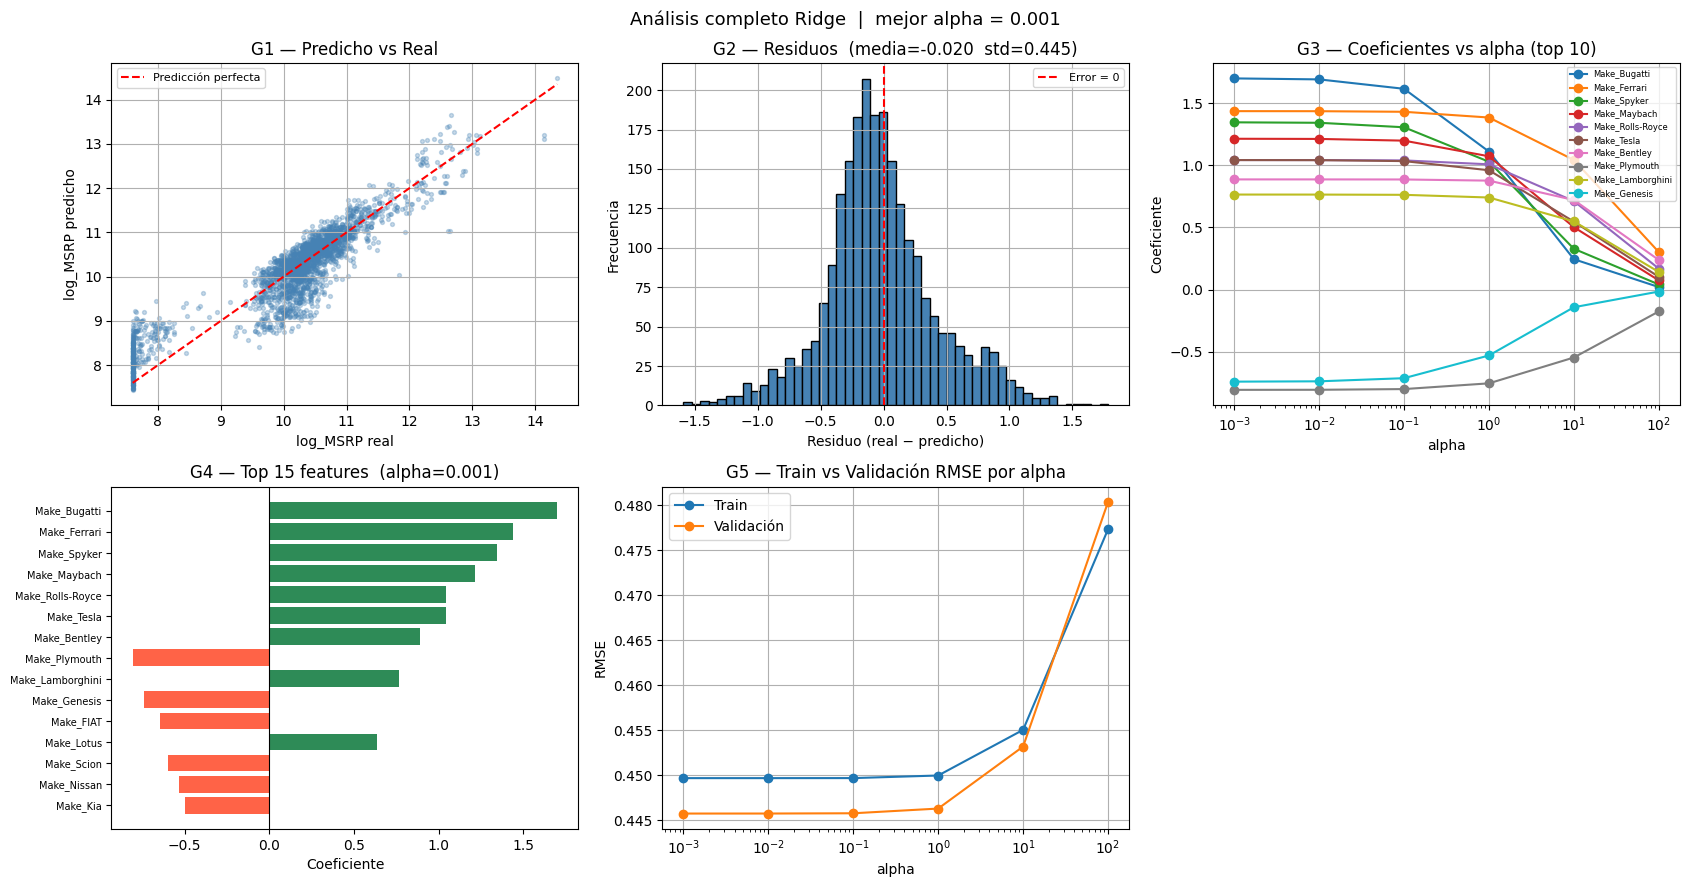

In [26]:
best_ridge_viz = Ridge(alpha=best_alpha, random_state=42)
best_ridge_viz.fit(X_train_full, train['log_MSRP'])
pred_viz = best_ridge_viz.predict(X_val_full)

fig, axes = plt.subplots(2, 3, figsize=(17, 9))

# G1: Predicho vs Real
ax = axes[0, 0]
ax.scatter(val['log_MSRP'], pred_viz, alpha=0.3, s=8, color='steelblue')
lims = [val['log_MSRP'].min(), val['log_MSRP'].max()]
ax.plot(lims, lims, 'r--', label='Predicción perfecta')
ax.set_xlabel('log_MSRP real')
ax.set_ylabel('log_MSRP predicho')
ax.set_title('G1 — Predicho vs Real')
ax.legend(fontsize=8)
ax.grid(True)

# G2: Distribución de residuos
residuos = val['log_MSRP'].values - pred_viz
ax = axes[0, 1]
ax.hist(residuos, bins=50, color='steelblue', edgecolor='black')
ax.axvline(0, color='red', linestyle='--', label='Error = 0')
ax.set_xlabel('Residuo (real − predicho)')
ax.set_ylabel('Frecuencia')
ax.set_title(f'G2 — Residuos  (media={residuos.mean():.3f}  std={residuos.std():.3f})')
ax.legend(fontsize=8)
ax.grid(True)

# G3: Coeficientes vs alpha
coef_history = []
for a in alphas:
    r = Ridge(alpha=a, random_state=42)
    r.fit(X_train_full, train['log_MSRP'])
    coef_history.append(r.coef_)

coef_df = pd.DataFrame(coef_history, index=alphas, columns=X_train_full.columns)
top_feats = coef_df.abs().max().sort_values(ascending=False).head(10).index

ax = axes[0, 2]
for feat in top_feats:
    ax.plot(alphas, coef_df[feat], marker='o', label=feat, linewidth=1.5)
ax.set_xscale('log')
ax.set_xlabel('alpha')
ax.set_ylabel('Coeficiente')
ax.set_title('G3 — Coeficientes vs alpha (top 10)')
ax.legend(fontsize=6, loc='upper right')
ax.grid(True)

# G4: Top 15 features por magnitud
coef_series = pd.Series(best_ridge_viz.coef_, index=X_train_full.columns)
top15_vals = coef_series[coef_series.abs().sort_values(ascending=False).head(15).index]
colors = ['seagreen' if v > 0 else 'tomato' for v in top15_vals]

ax = axes[1, 0]
ax.barh(top15_vals.index[::-1], top15_vals.values[::-1], color=colors[::-1])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coeficiente')
ax.set_title(f'G4 — Top 15 features  (alpha={best_alpha})')
ax.tick_params(axis='y', labelsize=7)

# G5: Train vs Validación RMSE por alpha
train_rmse_list, val_rmse_list = [], []
for a in alphas:
    r = Ridge(alpha=a, random_state=42)
    r.fit(X_train_full, train['log_MSRP'])
    train_rmse_list.append(rmse(train['log_MSRP'], r.predict(X_train_full)))
    val_rmse_list.append(rmse(val['log_MSRP'], r.predict(X_val_full)))

ax = axes[1, 1]
ax.plot(alphas, train_rmse_list, marker='o', label='Train')
ax.plot(alphas, val_rmse_list, marker='o', label='Validación')
ax.set_xscale('log')
ax.set_xlabel('alpha')
ax.set_ylabel('RMSE')
ax.set_title('G5 — Train vs Validación RMSE por alpha')
ax.legend()
ax.grid(True)

axes[1, 2].axis('off')

plt.suptitle(f'Análisis completo Ridge  |  mejor alpha = {best_alpha}', fontsize=13)
plt.tight_layout()
plt.show()

## Ejercicio 5: Tabla resumen
Se compara el baseline y los modelos entrenados.

In [13]:
baseline_pred = np.full_like(test['log_MSRP'], train_val['log_MSRP'].mean(), dtype=float)
rmse_baseline = rmse(test['log_MSRP'], baseline_pred)

summary = pd.DataFrame([
    ['Baseline (media log MRP)', '—', rmse_baseline],
    ['Lineal 2 features', 'Year, Engine HP', rmse_val2],
    ['Lineal 5 features', 'Year, Engine HP, Engine Cylinders, highway MPG, city mpg', rmse_val5],
    ['Lineal todas las features', 'Numéricas + Make OHE', rmse_val_full],
    [f'Ridge alpha={best_alpha}', 'Numéricas + Make OHE', rmse_test_final],
], columns=['Modelo', 'Features', 'RMSE val/test'])
summary

,Modelo,Features,RMSE val/test
0,Baseline (media log MRP),—,1.124799
1,Lineal 2 features,"Year, Engine HP",0.526059
2,Lineal 5 features,"Year, Engine HP, Engine Cylinders, highway MPG...",0.521995
3,Lineal todas las features,Numéricas + Make OHE,0.445752
4,Ridge alpha=0.001,Numéricas + Make OHE,0.442167
